## Imports (Refactored)

In [1]:
# System & utilities
import os
import zipfile
import hashlib

# Data processing
import numpy as np
import tqdm

# Image / video
import cv2

# Download helper
import gdown

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

2026-04-03 14:49:10.901446: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775227751.106890      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775227751.166902      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775227751.652801      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775227751.652836      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775227751.652839      55 computation_placer.cc:177] computation placer alr

## Dataset Download

In [2]:
GOOGLE_DRIVE_ID = "1KCKfyIGbQi8a7bIYta3LM8dFStxVzVX-"
ZIP_NAME = "video_dataset.zip"

download_url = f"https://drive.google.com/uc?id={GOOGLE_DRIVE_ID}"

gdown.download(download_url, ZIP_NAME, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1KCKfyIGbQi8a7bIYta3LM8dFStxVzVX-
From (redirected): https://drive.google.com/uc?id=1KCKfyIGbQi8a7bIYta3LM8dFStxVzVX-&confirm=t&uuid=b549e8cd-cd4b-4876-b6aa-2ed287ea5d73
To: /kaggle/working/video_dataset.zip
100%|██████████| 1.78G/1.78G [00:16<00:00, 110MB/s] 


'video_dataset.zip'

## Extraction

In [3]:
DATA_ROOT = "dataset_root"

with zipfile.ZipFile(ZIP_NAME, "r") as zf:
    zf.extractall(DATA_ROOT)

## Directory Mapping

In [4]:
DATASET_BASE = os.path.join(DATA_ROOT, "Shop DataSet")

CLASS_DIRS = {
    0: os.path.join(DATASET_BASE, "non shop lifters"),
    1: os.path.join(DATASET_BASE, "shop lifters")
}

for label, folder in CLASS_DIRS.items():
    print(f"class {label} count:", len(os.listdir(folder)))

class 0 count: 531
class 1 count: 324


## Duplicate Detection (Optimized)

In [5]:
def md5_signature(file_path):
    md5 = hashlib.md5()

    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            md5.update(chunk)

    return md5.hexdigest()


def find_duplicate_files(directories):
    registry = {}
    duplicates = []

    for folder in directories:
        for fname in os.listdir(folder):
            fpath = os.path.join(folder, fname)
            signature = md5_signature(fpath)

            if signature in registry:
                duplicates.append((fpath, registry[signature]))
            else:
                registry[signature] = fpath

    return duplicates


duplicates = find_duplicate_files(CLASS_DIRS.values())
print("Duplicate files:", len(duplicates))

Duplicate files: 218


## Remove Duplicates

In [6]:
def delete_duplicates(duplicate_pairs):
    removed = 0

    for dup_path, _ in duplicate_pairs:
        if os.path.exists(dup_path):
            os.remove(dup_path)
            removed += 1

    return removed


removed_count = delete_duplicates(duplicates)
print("Removed duplicates:", removed_count)

Removed duplicates: 218


## Build Dataset

In [7]:
def collect_dataset(class_dirs):
    paths, targets = [], []

    for label, directory in class_dirs.items():
        for file in os.listdir(directory):
            paths.append(os.path.join(directory, file))
            targets.append(label)

    return paths, targets


video_paths, labels = collect_dataset(CLASS_DIRS)

print("Dataset size:", len(video_paths))

Dataset size: 637


## Frame Analysis

In [8]:
def compute_frame_stats(paths):
    counts = []

    for path in paths:
        cap = cv2.VideoCapture(path)
        counts.append(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
        cap.release()

    return counts


frame_counts = compute_frame_stats(video_paths)

print("Min:", min(frame_counts))
print("Max:", max(frame_counts))
print("Avg:", int(np.mean(frame_counts)))

Min: 75
Max: 1850
Avg: 324


## Frame Sampling

In [9]:
def sample_sequence(video_path, num_frames=16, size=128):
    cap = cv2.VideoCapture(video_path)

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total - 1, num_frames).astype(int)

    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, frame = cap.read()

        if not ok:
            continue

        frame = cv2.resize(frame, (size, size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        frames.append(frame)

    cap.release()

    return np.array(frames) / 255.0

## Train / Val / Test Split

In [10]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    video_paths,
    labels,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Train: 445
Val: 96
Test: 96


## Sequence Extraction + Augmentation

In [11]:
MAX_SEQ = 20
IMG_SIZE = 128


def build_video_tensor(path, augment=False):
    cap = cv2.VideoCapture(path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // MAX_SEQ, 1)

    frames = []

    for i in range(MAX_SEQ):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ok, frame = cap.read()

        if not ok:
            break

        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        if augment:
            if np.random.rand() > 0.5:
                frame = cv2.flip(frame, 1)
            if np.random.rand() > 0.7:
                frame = cv2.rotate(frame, cv2.ROTATE_90_CLOCKWISE)

        frames.append(frame)

    cap.release()

    frames = np.array(frames, dtype=np.float32)

    if len(frames) < MAX_SEQ:
        padding = np.zeros((MAX_SEQ - len(frames), IMG_SIZE, IMG_SIZE, 3))
        frames = np.concatenate([frames, padding])

    return frames / 255.0

## Data Loader

In [12]:
def create_dataset(paths, labels, augment=False):
    X, y = [], []

    for path, label in tqdm.tqdm(zip(paths, labels), total=len(paths)):
        X.append(build_video_tensor(path, augment))
        y.append(label)

    return np.array(X), np.array(y)


print("Loading train set...")
X_train, y_train = create_dataset(train_paths, train_labels, augment=True)

print("Loading validation set...")
X_val, y_val = create_dataset(val_paths, val_labels)

print("Loading test set...")
X_test, y_test = create_dataset(test_paths, test_labels)

Loading train set...


100%|██████████| 445/445 [05:47<00:00,  1.28it/s]


Loading validation set...


100%|██████████| 96/96 [01:17<00:00,  1.24it/s]


Loading test set...


100%|██████████| 96/96 [01:01<00:00,  1.57it/s]


## Class Weights

In [13]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

## MobileNet Feature Extractor

In [14]:
feature_extractor = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in feature_extractor.layers:
    layer.trainable = False

I0000 00:00:1775228292.779047      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775228292.785262      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Model Architecture (Cleaner Design)

In [15]:
def build_model():
    inputs = tf.keras.Input(shape=(MAX_SEQ, IMG_SIZE, IMG_SIZE, 3))

    x = layers.TimeDistributed(feature_extractor)(inputs)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    return tf.keras.Model(inputs, outputs)


model = build_model()

## Compile

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20, 128, 128,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 20, 4, 4, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 20, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Callbacks

In [17]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6
    )
]

##  Training

In [18]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=4,
    callbacks=callbacks
)

Epoch 1/100


I0000 00:00:1775228364.098158    7135 service.cc:152] XLA service 0x7ee750002f10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775228364.098201    7135 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775228364.098205    7135 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775228381.199592    7135 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-03 14:59:52.067530: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-03 14:59:52.221515: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-03 14:59:52.357261: E external/local_xl

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5250 - loss: 0.8881

2026-04-03 15:00:48.750786: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-03 15:00:48.884811: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


112/112 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.5257 - loss: 0.8856 - val_accuracy: 0.6979 - val_loss: 0.5887 - learning_rate: 1.0000e-04
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6602 - loss: 0.6326 - val_accuracy: 0.6771 - val_loss: 0.5503 - learning_rate: 1.0000e-04
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6703 - loss: 0.5918 - val_accuracy: 0.8750 - val_loss: 0.4658 - learning_rate: 1.0000e-04
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.7479 - loss: 0.5261 - val_accuracy: 0.8750 - val_loss: 0.4383 - learning_rate: 1.0000e-04
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.8132 - loss: 0.4618 - val_accuracy: 0.9062 - val_loss: 0.4225 - learning_rate: 1.0000e-04
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8416 - loss: 0.4152 - val_accuracy: 0.9271 - val_loss: 0.3662 - learning_rate: 1.0000e-04
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy

## Evaluation

In [19]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred))

2026-04-03 15:10:45.843455: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-03 15:10:45.983659: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 237ms/step
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        47
           1       0.96      1.00      0.98        49

    accuracy                           0.98        96
   macro avg       0.98      0.98      0.98        96
weighted avg       0.98      0.98      0.98        96



## Visualization

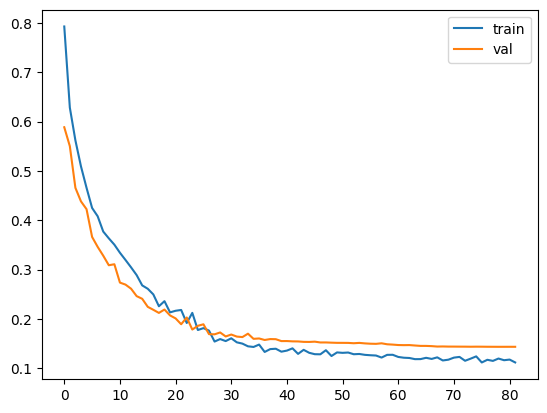

In [20]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.show()

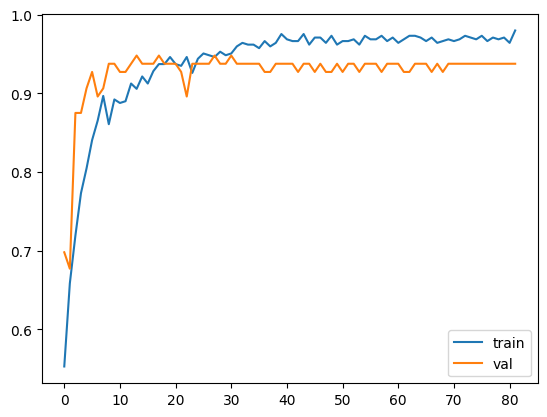

In [21]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.legend()
plt.show()

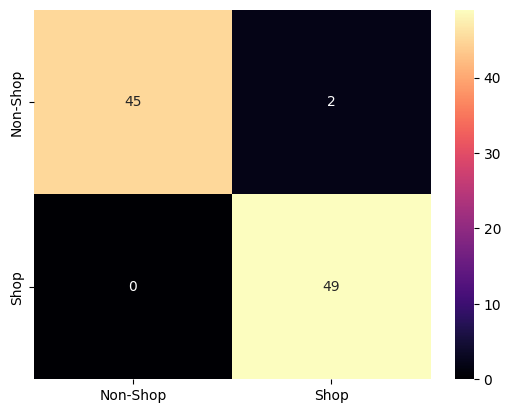

In [22]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="magma",
    xticklabels=["Non-Shop", "Shop"],
    yticklabels=["Non-Shop", "Shop"]
)

plt.show()

## Save Model

In [23]:
model.save("video_classification_model.h5")